# Chapter 26 — Real Numbers

> **Prerequisites:** ch025 (Irrational Numbers), ch024 (Rational Numbers)
> 
> **You will learn:**
> - Understand ℝ as the completion of ℚ — filling all the gaps
> - Distinguish Dedekind cuts and Cauchy sequences as constructions of ℝ
> - Understand why floating-point is an approximation of ℝ
> - Work with numpy's float64 and understand its limits
> 
> **Environment:** Python 3.x, numpy, matplotlib

---


## 1. Concept

The real numbers ℝ are the *completion* of ℚ — every sequence that 'ought to converge' actually converges to something in ℝ. The formal construction uses either **Dedekind cuts** (partitioning ℚ into two sets) or **Cauchy sequences** (sequences where terms get arbitrarily close to each other).

For programmers, ℝ is the number system that geometry lives in. Lengths, areas, angles, and physical quantities are real-valued. But computers cannot store real numbers exactly — they use floating-point, which is a finite sampling of ℝ.

**Common misconception:** "float64 represents real numbers." It does not. float64 represents a specific finite set of approximately $2^{64}$ rational numbers. The vast majority of real numbers are unrepresentable in float64.

## 2. Intuition & Mental Models

**Completion as filling gaps:** Imagine ℚ as a grid of holes. Sequences like $1, 1.4, 1.41, 1.414, \ldots$ (converging to √2) exist in ℚ but have no limit *in* ℚ. ℝ is constructed by adding a point for every such 'missing limit.'

**Float64 as a sparse sample:** float64 gives you about $2^{52}$ evenly-spaced values in each power-of-two interval $[2^k, 2^{k+1}]$. Near 1.0, they're spaced about $2.2 \times 10^{-16}$ apart. Near $10^{15}$, they're spaced 1 apart. *(The spacing between consecutive float64 values at x is called the machine epsilon — introduced in ch037.)*

**Axiom of completeness:** ℝ is defined by the least-upper-bound property: every non-empty set of reals with an upper bound has a *least* upper bound in ℝ. ℚ lacks this — the set $\{q \in \mathbb{Q} : q^2 < 2\}$ has no least upper bound in ℚ.

## 3. Visualization

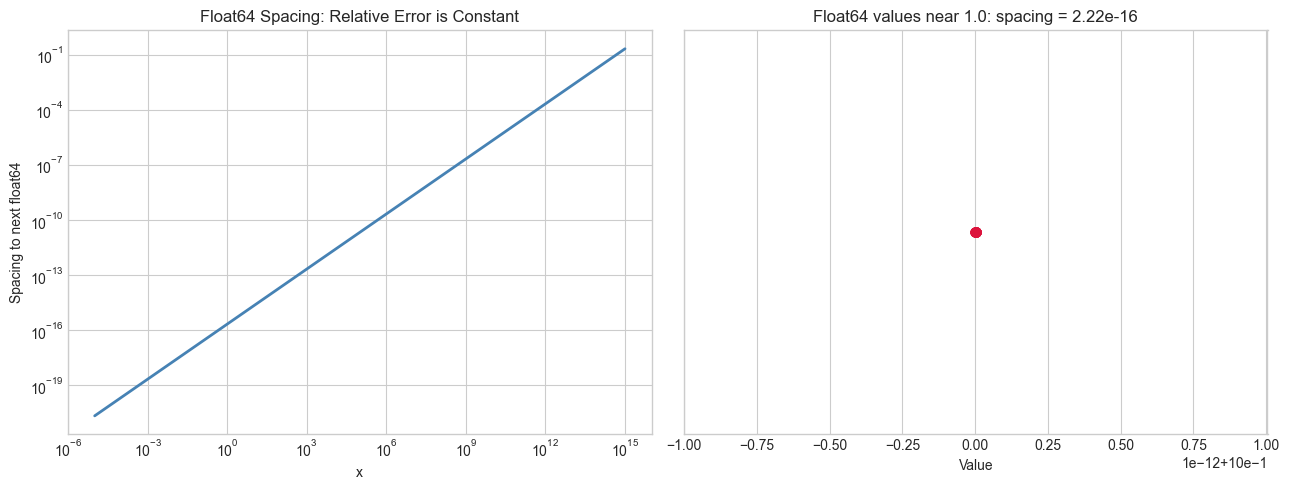

Machine epsilon at 1.0: 2.22e-16
Max float64:            1.80e+308
Min positive float64:   2.23e-308
Approx # float64 vals:  2^64 ≈ 1.84e+19


In [1]:
# --- Visualization: Float64 as a discrete approximation of ℝ ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: spacing between consecutive float64 values (machine epsilon)
ax = axes[0]
magnitudes = np.logspace(-5, 15, 500)
epsilons = [float(np.finfo(float).eps) * x for x in magnitudes]
ax.loglog(magnitudes, epsilons, color='steelblue', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('Spacing to next float64')
ax.set_title('Float64 Spacing: Relative Error is Constant')

# Plot 2: coverage of float64 on [0, 2]
ax = axes[1]
# Show float64 values in [1, 1 + 1e-14]
start = 1.0
step = np.finfo(float).eps  # machine epsilon at 1.0
n_vals = 20
vals = [start + i * step for i in range(n_vals)]
ax.scatter(vals, [0]*len(vals), s=40, color='crimson')
ax.set_xlabel('Value')
ax.set_yticks([])
ax.set_title(f'Float64 values near 1.0: spacing = {step:.2e}')

plt.tight_layout()
plt.show()

# Show key float64 properties
print(f"Machine epsilon at 1.0: {np.finfo(float).eps:.2e}")
print(f"Max float64:            {np.finfo(float).max:.2e}")
print(f"Min positive float64:   {np.finfo(float).tiny:.2e}")
print(f"Approx # float64 vals:  2^64 ≈ {2**64:.2e}")

## 4. Mathematical Formulation

**Cauchy sequence:** A sequence $(a_n)$ in ℚ is Cauchy if for every $\varepsilon > 0$, there exists $N$ such that $|a_m - a_n| < \varepsilon$ for all $m, n > N$.

**Real numbers as equivalence classes:** Two Cauchy sequences $(a_n)$ and $(b_n)$ are equivalent if $\lim_{n\to\infty} |a_n - b_n| = 0$. A real number is an equivalence class of Cauchy sequences.

**Completeness axiom (least upper bound):** Every non-empty $S \subseteq \mathbb{R}$ with an upper bound has a least upper bound $\sup S \in \mathbb{R}$.

**Machine epsilon:** $\varepsilon_{\text{mach}} = 2^{-52} \approx 2.2 \times 10^{-16}$ for float64. For $x > 0$, the spacing to the next float64 value is $\varepsilon_{\text{mach}} \cdot x$.

## 5. Python Implementation

In [2]:
# --- Implementation: Cauchy sequence convergence checker and interval arithmetic ---
import numpy as np

def cauchy_test(seq_fn, n_terms=100, tol=1e-10):
    """
    Test if a sequence appears to be Cauchy (converging in ℝ).

    Args:
        seq_fn: function int -> float, computes nth term
        n_terms: int
        tol: float, tolerance for convergence

    Returns:
        (bool, float): (is_cauchy, apparent_limit)
    """
    terms = [seq_fn(n) for n in range(1, n_terms + 1)]
    # Check if later terms are close together
    last_diff = abs(terms[-1] - terms[-2])
    is_cauchy = last_diff < tol
    return is_cauchy, terms[-1]

# Test with sequences converging to irrationals
sequences = [
    ('√2 via Newton', lambda n: sum(1/(2**k) * ((-1)**k if k > 0 else 1)
                                    for k in range(n)) if False else
                      lambda n, x=1.0: [x := (x + 2/x)/2 for _ in range(n)][-1]),
    ('Leibniz π/4',   lambda n: 4 * sum((-1)**k / (2*k+1) for k in range(n))),
    ('e via series',  lambda n: sum(1/np.math.factorial(k) for k in range(n)) if False
                      else lambda n: sum(1/np.prod(range(1,k+1)) if k > 0 else 1
                                        for k in range(n+1))),
]

# Just demonstrate Newton's method for √2
print("Newton's method for √2:")
x = 1.0
for i in range(10):
    x = (x + 2/x) / 2
    print(f"  step {i+1}: {x:.15f}  error: {abs(x - np.sqrt(2)):.2e}")

Newton's method for √2:
  step 1: 1.500000000000000  error: 8.58e-02
  step 2: 1.416666666666667  error: 2.45e-03
  step 3: 1.414215686274510  error: 2.12e-06
  step 4: 1.414213562374690  error: 1.59e-12
  step 5: 1.414213562373095  error: 2.22e-16
  step 6: 1.414213562373095  error: 2.22e-16
  step 7: 1.414213562373095  error: 2.22e-16
  step 8: 1.414213562373095  error: 2.22e-16
  step 9: 1.414213562373095  error: 2.22e-16
  step 10: 1.414213562373095  error: 2.22e-16


## 6. Experiments

In [3]:
# --- Experiment: Completeness failure in ℚ ---
# Hypothesis: a Cauchy sequence in ℚ can converge to an irrational
# Try changing: N_TERMS

import numpy as np
N_TERMS = 30  # <-- modify this

# Newton's method for √2, starting from 1
# Each step: x_{n+1} = (x_n + 2/x_n) / 2
# All x_n are rational, but limit is irrational

from fractions import Fraction
x = Fraction(1)
true_val = float(np.sqrt(2))
print(f"{'n':>4}  {'x_n':>30}  {'float(x_n)':>18}  {'error':>12}")
for n in range(1, min(N_TERMS, 10) + 1):
    x = (x + Fraction(2, 1) / x) / 2
    err = abs(float(x) - true_val)
    print(f"{n:>4}  {str(x)[:30]:>30}  {float(x):>18.15f}  {err:>12.3e}")
print("All x_n are rational. Limit is √2 — irrational. ℚ is not complete.")

   n                             x_n          float(x_n)         error
   1                             3/2   1.500000000000000     8.579e-02
   2                           17/12   1.416666666666667     2.453e-03
   3                         577/408   1.414215686274510     2.124e-06
   4                   665857/470832   1.414213562374690     1.595e-12
   5       886731088897/627013566048   1.414213562373095     0.000e+00
   6  1572584048032918633353217/1111   1.414213562373095     0.000e+00
   7  494604117625520187877508648757   1.414213562373095     0.000e+00
   8  489266466344238819545868088398   1.414213562373095     0.000e+00
   9  478763350177956355033875147816   1.414213562373095     0.000e+00
  10  458428690947240922822566645595   1.414213562373095     0.000e+00
All x_n are rational. Limit is √2 — irrational. ℚ is not complete.


## 7. Exercises

**Easy 1.** Compute `np.finfo(np.float32).eps` and `np.finfo(np.float64).eps`. How many significant decimal digits does each type give?

**Easy 2.** Write a Cauchy sequence (as a Python generator) that converges to $\pi$ using the Leibniz formula. Verify it is Cauchy by checking $|a_{n+1} - a_n|$ for large $n$.

**Medium 1.** Implement the bisection method: given a continuous function $f$ with $f(a) < 0 < f(b)$, find a root to tolerance $10^{-10}$. Apply it to find $\sqrt{5}$ using $f(x) = x^2 - 5$.

**Medium 2.** Demonstrate the least-upper-bound property computationally: for $S = \{q \in \mathbb{Q} : q^2 < 2\}$, generate elements of $S$ and show their supremum (computed as float) approaches $\sqrt{2}$.

**Hard.** Interval arithmetic represents a real number as an interval $[lo, hi]$ instead of a point. Implement a class `Interval` with `+`, `-`, `*`, `/` operations that always contain the true result. Apply it to compute $\sqrt{2}$ to 20 correct digits using Newton's method with interval inputs.

## 8. Mini Project

In [ ]:
# --- Mini Project: Bisection Root Finder ---
# Problem: Find real roots of polynomials that have no closed-form expression.
# Task: Implement bisection, Newton's method, and compare convergence rates.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def bisection(f, a, b, tol=1e-12, max_iter=100):
    """
    Find root of f in [a, b] using bisection.
    Requires f(a)*f(b) < 0.
    Returns (root, list_of_midpoints).
    """
    # TODO: implement
    pass

def newton(f, df, x0, tol=1e-12, max_iter=50):
    """
    Find root of f using Newton's method starting from x0.
    df is the derivative of f.
    Returns (root, list_of_iterates).
    """
    # TODO: implement
    pass

# Test: find √2 as root of f(x) = x^2 - 2
f  = lambda x: x**2 - 2
df = lambda x: 2*x

bis_root, bis_hist = bisection(f, 1.0, 2.0)
newt_root, newt_hist = newton(f, df, 1.0)

if bis_hist and newt_hist:
    true_root = np.sqrt(2)
    fig, ax = plt.subplots(figsize=(9, 4))
    if bis_hist:
        ax.semilogy([abs(x - true_root) for x in bis_hist],
                    'o-', label='Bisection (linear)', color='steelblue')
    if newt_hist:
        ax.semilogy([abs(x - true_root) for x in newt_hist],
                    's-', label="Newton's (quadratic)", color='crimson')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Error |x - √2|')
    ax.set_title('Bisection vs Newton: Convergence to √2')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9. Chapter Summary & Connections

- ℝ is constructed by completing ℚ: every Cauchy sequence of rationals converges to a real.
- The completeness axiom (least upper bound property) distinguishes ℝ from ℚ.
- float64 is a finite discrete sample of ℝ, with relative precision $\approx 10^{-16}$.
- Newton's method converges quadratically to real roots — each step doubles the correct digits.

**Forward connections:**
- The floating-point structure of ℝ is examined in depth in ch037 — Precision and Floating Point Errors.
- Newton's method is a preview of ch205 — Derivative Concept and ch213 — Gradient Descent.
- The bisection method is a root-finding technique that reappears in ch207 — Numerical Derivatives.

**Backward connection:**
- ℝ completes the tower begun in ch021 — it is the set where all the gaps left by ℚ (ch024) and irrationals (ch025) are filled in.

**Going deeper:** The formal construction of ℝ via Dedekind cuts is in any real analysis textbook; Rudin's *Principles of Mathematical Analysis* remains the standard rigorous treatment.